# Chapter 3, Exercise 1: Aliasing a 9 kHz tone at 16 kHz

> **How to use this notebook.** Open it in Google Colab (File > Upload notebook, or the Colab badge on the companion website), then run the cells from top to bottom. Runtime > Change runtime type lets you pick a GPU when one is recommended below. Everything else runs on the free CPU tier.

## The exercise

**Chapter 3, Exercise 1.** Using Python, generate a 9 kHz sine wave and sample it at 16 kHz with no anti-aliasing filter; plot the spectrogram and report the frequency at which the aliased tone appears. Then state the minimum sampling rate that would avoid aliasing for content up to 7 kHz, the standard rate you would choose in practice, and where the anti-aliasing cutoff should sit.

## Requirements

No GPU is required; the notebook runs on Colab's free CPU runtime.


<a href="https://colab.research.google.com/github/arabic-speech-book/arabic-speech-book.github.io/blob/main/docs/solutions/Chapter_03_Exercise_01.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

## 1. Sample a 9 kHz tone at 16 kHz, with no anti-aliasing filter

Sampling at 16 kHz can only represent frequencies below the Nyquist limit of 8 kHz (Table 3.1). A 9 kHz tone lies 1 kHz *above* that limit, so it folds back to 8 kHz minus 1 kHz = **7 kHz**. We evaluate the sine directly at the 16 kHz sample instants, which is exactly what an analog-to-digital converter without an anti-aliasing filter would do.

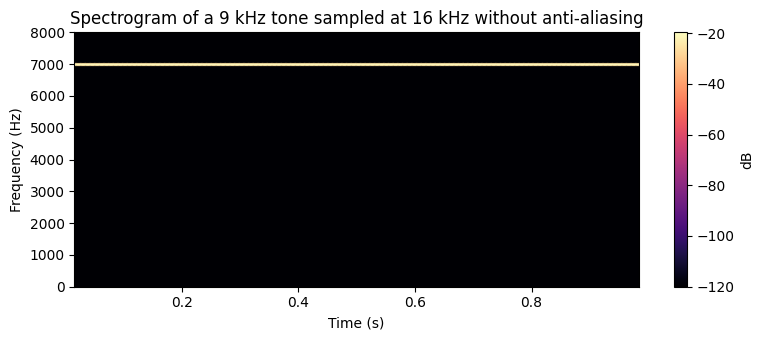

The tone appears at 7000 Hz (expected alias: 7000 Hz)


In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy import signal

fs = 16_000          # sampling rate (Hz)
f_tone = 9_000       # tone frequency (Hz), above Nyquist = fs/2 = 8 kHz
dur = 1.0            # seconds
t = np.arange(int(fs*dur)) / fs
x = np.sin(2*np.pi*f_tone*t)   # "sampled" 9 kHz tone, no anti-aliasing filter

f, tt, Sxx = signal.spectrogram(x, fs=fs, nperseg=512, noverlap=384, window='hann')
plt.figure(figsize=(8, 3.5))
plt.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='magma')
plt.ylabel('Frequency (Hz)'); plt.xlabel('Time (s)')
plt.title('Spectrogram of a 9 kHz tone sampled at 16 kHz without anti-aliasing')
plt.colorbar(label='dB'); plt.tight_layout(); plt.show()

# Locate the peak frequency in the average spectrum
peak_hz = f[np.argmax(Sxx.mean(axis=1))]
print(f"The tone appears at {peak_hz:.0f} Hz (expected alias: {fs - f_tone} Hz)")

## 2. Why 7 kHz: the folding rule

For a tone at frequency $f$ sampled at $f_s$, the observed frequency is the distance from $f$ to the nearest integer multiple of $f_s$, folded into the range $[0, f_s/2]$. Here $|9000 - 16000| = 7000$ Hz. The corruption is irreversible: the samples of the 9 kHz tone are *identical* to the samples of a 7 kHz tone, as the next cell shows.

In [2]:
x_alias = np.sin(2*np.pi*(fs - f_tone)*t)          # a genuine 7 kHz tone
print("max |x(9 kHz) + x(7 kHz)| =", np.abs(x + x_alias).max().round(6))
# The 9 kHz samples equal the negative of the 7 kHz samples: same tone, phase flipped.

max |x(9 kHz) + x(7 kHz)| = 0.0


## 3. What an anti-aliasing filter would have done

To show the fix, we simulate the "analog" signal at a high rate (192 kHz), apply a low-pass filter below the target Nyquist limit, and only then decimate to 16 kHz. The 9 kHz tone is removed rather than folded.

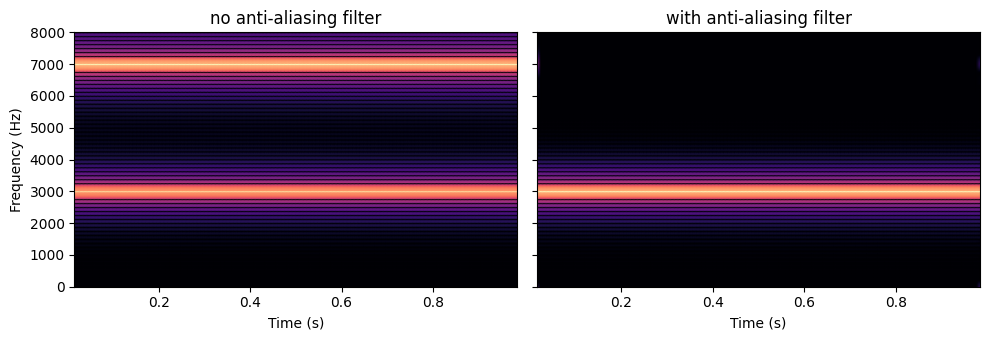

Left: the 9 kHz tone folds to 7 kHz beside the real 3 kHz tone.
Right: only the 3 kHz tone survives; the 9 kHz content was removed before sampling.


In [3]:
fs_hi = 192_000
t_hi = np.arange(int(fs_hi*dur)) / fs_hi
x_hi = np.sin(2*np.pi*f_tone*t_hi) + 0.5*np.sin(2*np.pi*3_000*t_hi)   # 9 kHz (illegal) + 3 kHz (legal)

# Anti-aliasing low-pass: passband to 7 kHz, stopband from 8 kHz, then decimate by 12
sos = signal.iirdesign(wp=7_000, ws=8_000, gpass=0.5, gstop=60, fs=fs_hi, output='sos')
x_filt = signal.sosfiltfilt(sos, x_hi)
x_dec  = x_filt[::fs_hi // fs]          # now at 16 kHz
x_bad  = x_hi[::fs_hi // fs]            # decimated WITHOUT the filter

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for a, sig, title in [(ax[0], x_bad, 'no anti-aliasing filter'), (ax[1], x_dec, 'with anti-aliasing filter')]:
    f, tt, S = signal.spectrogram(sig, fs=fs, nperseg=512, noverlap=384)
    a.pcolormesh(tt, f, 10*np.log10(S + 1e-12), shading='gouraud', cmap='magma')
    a.set_title(title); a.set_xlabel('Time (s)')
ax[0].set_ylabel('Frequency (Hz)'); plt.tight_layout(); plt.show()
print("Left: the 9 kHz tone folds to 7 kHz beside the real 3 kHz tone.")
print("Right: only the 3 kHz tone survives; the 9 kHz content was removed before sampling.")

## 4. Answers to the design questions

| Question | Answer |
|---|---|
| Frequency at which the aliased tone appears | **7 kHz** (= 16 kHz minus 9 kHz) |
| Minimum sampling rate for content up to 7 kHz | Strictly **more than 14 kHz** (Nyquist: $f_s > 2 \times 7$ kHz). Exactly 14 kHz is the theoretical boundary and leaves no room for a filter transition band. |
| Standard rate in practice | **16 kHz**, the common default for speech recognition (Table 3.1); it keeps the useful band to 8 kHz and matches most pretrained models. |
| Where the anti-aliasing cutoff should sit | **Below the Nyquist limit of 8 kHz**: passband edge around 7 kHz with the stopband reaching full attenuation by 8 kHz, as in the filter above. Real filters are not brick walls, so the transition band must fit between the highest wanted frequency and Nyquist. |

Remember the chapter's pitfall: resampling an already-aliased or already-band-limited recording cannot undo the damage. The filter must act *before* the rate is reduced.